Generative Adversarial Networks (GANs)
======================

Artigo original: [Goodfellow et al (2020)](https://dl.acm.org/doi/abs/10.1145/3422622)

Duas redes generativas "competem" em um contexto determinado.

A rede Generativa, por meio de um vetor D-dimensional $V_{noise}$ gera imagens "falsas", as quais são embaralhadas a imagens reais.
A rede Discriminativa deve identificar as imagens reais e as imagens falsas.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import os

Espaço latente
===============

Espaço latente é um espaço de dimensão reduzida onde os dados são representados de maneira compacta e significativa. Os vetores latentes são pontos neste espaço. Cada vetor latente pode ser mapeado para uma amostra no espaço original dos dados (por exemplo, uma imagem, texto ou som).

Vetor latente
______________

1. **Representação Compacta:** Um vetor latente é uma representação compacta e densa de uma amostra. Por exemplo, uma imagem de alta resolução pode ser representada por um vetor latente de dimensão muito menor do que o número total de pixels da imagem.

2. **Dimensionalidade Reduzida:** O vetor latente possui uma dimensionalidade menor em comparação com os dados originais, o que ajuda a capturar os padrões mais importantes dos dados. Isso significa que o vetor latente retém as informações mais relevantes de maneira condensada.

3. **Entrada para Modelos Geradores:** Em modelos como GANs, o vetor latente serve como entrada para o gerador, que transforma esse vetor em uma amostra do espaço original (como uma imagem, som ou texto). Diferentes vetores latentes podem gerar diferentes amostras, e pequenas mudanças no vetor latente podem resultar em variações na amostra gerada.

In [2]:
# Parâmetros
latent_dim = 120

In [3]:
img_shape = (3, 64, 64)
batch_size = 64
epochs = 500
learning_rate = 0.001

In [4]:
# Dispositivo (CPU ou GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
import os
import shutil

# Define the path where the dataset will be stored
data_path = './data/trump_faces'
repo_url = 'https://github.com/alexge233/trump_make.git'
cloned_repo_dir = 'temp_repo'
source_images_subdir = os.path.join(cloned_repo_dir, 'data', 'trump', 'trump_faces')

# Clean up previous downloads if they exist
if os.path.exists(data_path):
    shutil.rmtree(data_path)
    print(f"Removed existing data directory: {data_path}")
if os.path.exists(cloned_repo_dir):
    shutil.rmtree(cloned_repo_dir)
    print(f"Removed existing temporary repository: {cloned_repo_dir}")

# Clone the repository
print(f"Cloning {repo_url} into {cloned_repo_dir}...")
!git clone {repo_url} {cloned_repo_dir}

# Ensure the target directory for images exists
os.makedirs(data_path, exist_ok=True)

# Move contents (actual images) from the source subdirectory to data_path
if os.path.exists(source_images_subdir):
    print(f"Moving image files from {source_images_subdir} to {data_path}...")
    for filename in os.listdir(source_images_subdir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            shutil.move(os.path.join(source_images_subdir, filename), data_path)
    print(f"Successfully moved {len([f for f in os.listdir(data_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])} image files.")
else:
    print(f"Error: Source image directory not found: {source_images_subdir}")

# Remove the temporary cloned repository
if os.path.exists(cloned_repo_dir):
    shutil.rmtree(cloned_repo_dir)
    print(f"Removed temporary repository: {cloned_repo_dir}")

print(f"Trump faces dataset successfully prepared in {data_path}")

# List some files to verify
print("First 5 image files in the dataset:")
image_files_in_data_path = [f for f in os.listdir(data_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
if image_files_in_data_path:
    for i, filename in enumerate(image_files_in_data_path):
        if i >= 5:
            break
        print(filename)
else:
    print("No image files found in the specified data_path after extraction.")

Cloning https://github.com/alexge233/trump_make.git into temp_repo...
Cloning into 'temp_repo'...
remote: Enumerating objects: 894, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 894 (delta 28), reused 10 (delta 2), pack-reused 836 (from 2)
Receiving objects: 100% (894/894), 18.45 MiB | 22.20 MiB/s, done.
Resolving deltas: 100% (77/77), done.
Moving image files from temp_repo/data/trump/trump_faces to ./data/trump_faces...
Successfully moved 710 image files.
Removed temporary repository: temp_repo
Trump faces dataset successfully prepared in ./data/trump_faces
First 5 image files in the dataset:
402.jpg_0.jpg
175.jpg_0.jpg
1504.jpg_0.jpg
127.jpg_0.jpg
1323.jpg_0.jpg


In [6]:
import torchvision.transforms as transforms

# Pipeline para transformação de dados para imagens 64x64 RGB
transform = transforms.Compose([
    transforms.Resize((img_shape[1], img_shape[2])), # Redimensiona para 64x64
    transforms.ToTensor(),                          # Converte para tensor [0, 1]
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])              # Normaliza para [-1, 1]
])

In [7]:
from PIL import Image
from torch.utils.data import Dataset
import os # Certifique-se de que 'os' está importado para operações de arquivo

# Custom Dataset para as faces do Trump
class TrumpFacesDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # Filtra apenas arquivos de imagem comuns
        self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.image_files[idx])
        # Abre a imagem como RGB para consistência antes de converter para escala de cinza, se necessário
        image = Image.open(img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, 0 # Retorna a imagem e um rótulo dummy (0), pois GANs não usam rótulos

# Carrega o novo dataset usando o caminho de dados definido anteriormente
dataset = TrumpFacesDataset(root_dir=data_path, transform=transform) # Usa o 'transform' globalmente definido
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Novo dataset carregado com {len(dataset)} imagens.")
print(f"Tamanho do batch para o novo dataloader: {batch_size}")

Novo dataset carregado com 710 imagens.
Tamanho do batch para o novo dataloader: 64


Gerador (Generator)
====================

* **Função:** Cria dados falsos que se pareçam com os dados reais. Ele recebe como entrada um vetor de ruído (também chamado de vetor latente), que é geralmente amostrado de uma distribuição simples, como uma distribuição normal. O gerador transforma esse vetor de ruído em uma amostra no espaço dos dados, como uma imagem, um texto, ou outro tipo de dado que se deseja gerar.

* **Estrutura:** O gerador é uma rede neural que geralmente contém camadas como `Linear`, `ConvTranspose2d`, `ReLU`, `BatchNorm`, etc. Essas camadas têm como objetivo transformar o vetor latente em uma representação complexa que, eventualmente, se torna uma amostra de dados semelhante às amostras reais do conjunto de treinamento.

* **Objetivo:** O objetivo do gerador é enganar o discriminador, fazendo com que ele classifique as amostras geradas como "reais". Durante o treinamento, os parâmetros do gerador são ajustados para maximizar a probabilidade de o discriminador classificar suas saídas como reais.

* **Função de Perda:** A função de perda do gerador geralmente tenta maximizar o valor logarítmico da probabilidade do discriminador classificar as amostras geradas como reais, ou, alternativamente, minimizar o valor logarítmico da probabilidade de o discriminador classificá-las como falsas.

In [8]:
# Gerador
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128 * 8 * 8),
            nn.BatchNorm1d(128 * 8 * 8),
            nn.ReLU(True),
            nn.Unflatten(1, (128, 8, 8)), # Start with 8x8 feature map
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),  # -> 64x64 output for RGB
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

Discriminador (Discriminator)
============================

* **Função:** O discriminador é responsável por distinguir entre amostras reais (do conjunto de treinamento) e amostras falsas (geradas pelo gerador). Ele recebe uma amostra como entrada e retorna uma probabilidade de que a amostra seja real (ou seja, pertencente ao conjunto de dados real) ou falsa (ou seja, gerada pelo gerador).

* **Estrutura:** O discriminador também é uma rede neural, mas geralmente é uma rede de classificação binária. Ele pode incluir camadas como `Conv2d`, `LeakyReLU`, `Flatten`, `Linear`, `Sigmoid`, etc. Essas camadas são projetadas para extrair características da entrada e decidir se a amostra é real ou falsa.

* **Objetivo:** O objetivo do discriminador é identificar corretamente se uma amostra é real ou falsa. Durante o treinamento, os parâmetros do discriminador são ajustados para maximizar a precisão na classificação de amostras reais e falsas.

* **Função de Perda:** A função de perda do discriminador é geralmente a soma das perdas de classificação das amostras reais e falsas. Ele tenta maximizar a probabilidade de classificar corretamente as amostras reais como reais e minimizar a probabilidade de classificar erroneamente as amostras falsas como reais.

In [9]:
# Discriminador
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),  # Input 64x64, Output 32x32
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # Input 32x32, Output 16x16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # Input 16x16, Output 8x8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 1), # Adjusted for final 8x8 feature map
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

In [10]:
# Instanciar os modelos
generator = Generator().to(device)
discriminator = Discriminator().to(device)

In [11]:
# Função de perda e otimizadores
criterion = nn.BCELoss().to(device)
optimizer_G = optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))

Interação entre Gerador e Discriminador - Adversarial learning
=====================================

1. **Treinamento Adversarial:** O treinamento de uma GAN envolve um jogo entre o gerador e o discriminador:

* O gerador tenta melhorar suas amostras para enganar o discriminador.
* O discriminador tenta melhorar sua capacidade de distinguir entre amostras reais e falsas.

2. **Ciclo de Treinamento:**
* Discriminador: É treinado primeiro em amostras reais e falsas. Ele aprende a identificar corretamente quais são reais e quais são falsas.
* Gerador: Após o discriminador ser treinado, o gerador é treinado para melhorar a qualidade de suas amostras, baseando-se no feedback que recebe do discriminador.

3. **Convergência:** Idealmente, o treinamento continua até que o discriminador não consiga mais distinguir entre amostras reais e geradas (ou seja, ambas têm 50% de chance de serem classificadas como reais), o que significa que o gerador está criando amostras realistas.

In [12]:
# Função para treinar o modelo
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.utils as vutils # Import vutils for making image grids

def train_dcgan(generator, discriminator, dataloader, criterion, optimizer_G, optimizer_D, epochs):
    # Get a fixed batch of real images for consistent comparison
    # fixed_real_batch = next(iter(dataloader))
    # fixed_real_imgs = fixed_real_batch[0][:25].to(device) # Get first 25 real images

    for epoch in range(epochs):
        for i, (imgs, _) in enumerate(dataloader):
            # Labels para real e falso
            real_labels = torch.ones(imgs.size(0), 1).to(device)
            fake_labels = torch.zeros(imgs.size(0), 1).to(device)

            # Treinar o Discriminador
            optimizer_D.zero_grad()
            real_imgs = imgs.to(device)
            real_loss = criterion(discriminator(real_imgs), real_labels)
            z = torch.randn(imgs.size(0), latent_dim).to(device)
            fake_imgs = generator(z)
            fake_loss = criterion(discriminator(fake_imgs.detach()), fake_labels)
            d_loss = real_loss + fake_loss
            d_loss.backward()
            optimizer_D.step()

            # Treinar o Gerador
            optimizer_G.zero_grad()
            g_loss = criterion(discriminator(fake_imgs), real_labels)
            g_loss.backward()
            optimizer_G.step()

            # Printar o progresso
            if i % 400 == 0:
                print(f"Epoch [{epoch}/{epochs}] Batch {i}/{len(dataloader)} Loss D: {d_loss.item():.4f}, Loss G: {g_loss.item():.4f}")

        # Salvar algumas imagens geradas após cada época
        img_filename = f"images_dgan/dcgan_{epoch}.png"
        save_image(fake_imgs[:25], img_filename, nrow=5, normalize=True)

        # Mostrar imagens geradas e reais para comparação a cada 5 épocas
        if epoch % 50 == 0 or epoch == epochs - 1:
            print(f"\n--- Comparação de Imagens na Época {epoch} ---")

            # Display Generated Images
            generated_image_grid = Image.open(img_filename)
            plt.figure(figsize=(12, 6))
            plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
            plt.imshow(generated_image_grid)
            plt.title(f"Imagens Geradas (Época {epoch})")
            plt.axis('off')

            # # Display Real Images
            # plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
            # plt.imshow(vutils.make_grid(fixed_real_imgs, padding=2, normalize=True).cpu().permute(1, 2, 0))
            # plt.title("Imagens Reais do Dataset")
            # plt.axis('off')

            plt.tight_layout()
            plt.show()

In [13]:
# Verificar e criar o diretório 'images' se ele não existir
if not os.path.exists('images_dgan'):
    os.makedirs('images_dgan')

Epoch [0/500] Batch 0/12 Loss D: 1.3765, Loss G: 2.1806

--- Comparação de Imagens na Época 0 ---


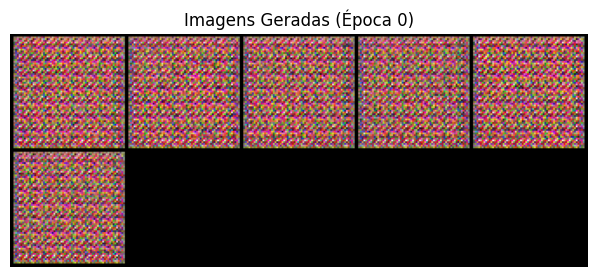

Epoch [1/500] Batch 0/12 Loss D: 0.8705, Loss G: 9.9943
Epoch [2/500] Batch 0/12 Loss D: 0.1008, Loss G: 6.9927
Epoch [3/500] Batch 0/12 Loss D: 0.0790, Loss G: 8.4487
Epoch [4/500] Batch 0/12 Loss D: 0.9824, Loss G: 6.7034
Epoch [5/500] Batch 0/12 Loss D: 0.2143, Loss G: 7.9591
Epoch [6/500] Batch 0/12 Loss D: 0.0879, Loss G: 9.3268
Epoch [7/500] Batch 0/12 Loss D: 0.1299, Loss G: 7.8256
Epoch [8/500] Batch 0/12 Loss D: 0.0349, Loss G: 5.4362
Epoch [9/500] Batch 0/12 Loss D: 0.2074, Loss G: 4.5854
Epoch [10/500] Batch 0/12 Loss D: 0.4178, Loss G: 7.1041
Epoch [11/500] Batch 0/12 Loss D: 0.5544, Loss G: 3.3052
Epoch [12/500] Batch 0/12 Loss D: 0.1665, Loss G: 4.7019
Epoch [13/500] Batch 0/12 Loss D: 0.3252, Loss G: 3.0786
Epoch [14/500] Batch 0/12 Loss D: 0.1105, Loss G: 6.3836
Epoch [15/500] Batch 0/12 Loss D: 1.7762, Loss G: 14.1528
Epoch [16/500] Batch 0/12 Loss D: 0.1497, Loss G: 5.5075
Epoch [17/500] Batch 0/12 Loss D: 0.2611, Loss G: 5.9303
Epoch [18/500] Batch 0/12 Loss D: 0.343

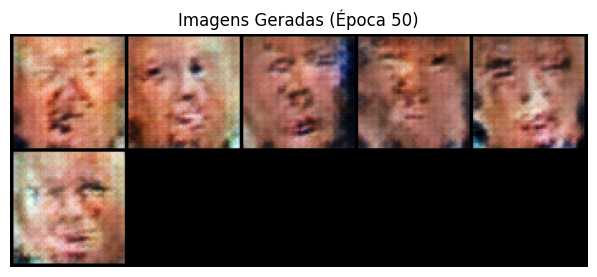

Epoch [51/500] Batch 0/12 Loss D: 2.6227, Loss G: 9.3609
Epoch [52/500] Batch 0/12 Loss D: 0.6118, Loss G: 1.9954
Epoch [53/500] Batch 0/12 Loss D: 0.3528, Loss G: 4.1817
Epoch [54/500] Batch 0/12 Loss D: 0.3692, Loss G: 3.2982
Epoch [55/500] Batch 0/12 Loss D: 2.3656, Loss G: 10.2600
Epoch [56/500] Batch 0/12 Loss D: 0.5110, Loss G: 2.5709
Epoch [57/500] Batch 0/12 Loss D: 0.3093, Loss G: 2.9275
Epoch [58/500] Batch 0/12 Loss D: 0.2898, Loss G: 5.0462
Epoch [59/500] Batch 0/12 Loss D: 0.2493, Loss G: 5.2575
Epoch [60/500] Batch 0/12 Loss D: 0.5878, Loss G: 2.3936
Epoch [61/500] Batch 0/12 Loss D: 0.5436, Loss G: 4.6771
Epoch [62/500] Batch 0/12 Loss D: 0.3370, Loss G: 5.4754
Epoch [63/500] Batch 0/12 Loss D: 0.3153, Loss G: 5.1755
Epoch [64/500] Batch 0/12 Loss D: 2.8041, Loss G: 7.7319
Epoch [65/500] Batch 0/12 Loss D: 0.4626, Loss G: 3.1821
Epoch [66/500] Batch 0/12 Loss D: 0.6632, Loss G: 5.6831
Epoch [67/500] Batch 0/12 Loss D: 0.2742, Loss G: 2.7124
Epoch [68/500] Batch 0/12 Loss

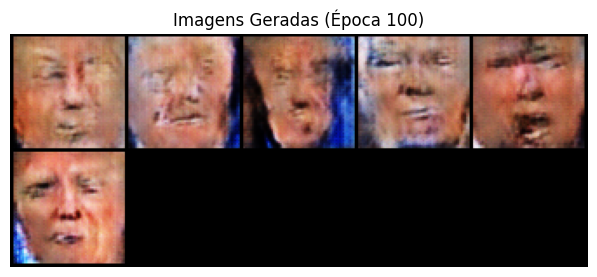

Epoch [101/500] Batch 0/12 Loss D: 0.2743, Loss G: 4.8543
Epoch [102/500] Batch 0/12 Loss D: 0.3737, Loss G: 4.7186
Epoch [103/500] Batch 0/12 Loss D: 0.2600, Loss G: 4.2442
Epoch [104/500] Batch 0/12 Loss D: 0.3022, Loss G: 5.7172
Epoch [105/500] Batch 0/12 Loss D: 0.1807, Loss G: 4.9240
Epoch [106/500] Batch 0/12 Loss D: 0.4044, Loss G: 6.8222
Epoch [107/500] Batch 0/12 Loss D: 0.2214, Loss G: 4.4058
Epoch [108/500] Batch 0/12 Loss D: 0.0912, Loss G: 4.6202
Epoch [109/500] Batch 0/12 Loss D: 0.1932, Loss G: 3.7064
Epoch [110/500] Batch 0/12 Loss D: 0.3081, Loss G: 5.7494
Epoch [111/500] Batch 0/12 Loss D: 0.2340, Loss G: 4.9113
Epoch [112/500] Batch 0/12 Loss D: 0.1814, Loss G: 5.4729
Epoch [113/500] Batch 0/12 Loss D: 5.4769, Loss G: 10.2374
Epoch [114/500] Batch 0/12 Loss D: 1.4896, Loss G: 3.9351
Epoch [115/500] Batch 0/12 Loss D: 0.7328, Loss G: 5.2996
Epoch [116/500] Batch 0/12 Loss D: 1.7266, Loss G: 7.7927
Epoch [117/500] Batch 0/12 Loss D: 0.3508, Loss G: 4.9498
Epoch [118/50

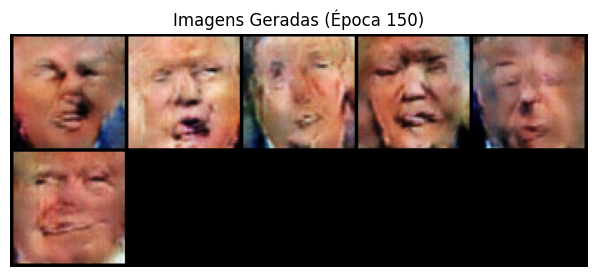

Epoch [151/500] Batch 0/12 Loss D: 1.2500, Loss G: 8.9495
Epoch [152/500] Batch 0/12 Loss D: 2.5024, Loss G: 2.6900
Epoch [153/500] Batch 0/12 Loss D: 0.7152, Loss G: 3.1295
Epoch [154/500] Batch 0/12 Loss D: 0.5567, Loss G: 5.3316
Epoch [155/500] Batch 0/12 Loss D: 0.4734, Loss G: 5.0687
Epoch [156/500] Batch 0/12 Loss D: 0.3156, Loss G: 4.5969
Epoch [157/500] Batch 0/12 Loss D: 0.3141, Loss G: 3.9092
Epoch [158/500] Batch 0/12 Loss D: 0.2560, Loss G: 3.3027
Epoch [159/500] Batch 0/12 Loss D: 1.8749, Loss G: 8.9277
Epoch [160/500] Batch 0/12 Loss D: 0.3130, Loss G: 3.7116
Epoch [161/500] Batch 0/12 Loss D: 0.2739, Loss G: 3.1527
Epoch [162/500] Batch 0/12 Loss D: 0.2541, Loss G: 3.1999
Epoch [163/500] Batch 0/12 Loss D: 0.5572, Loss G: 4.6789
Epoch [164/500] Batch 0/12 Loss D: 0.4295, Loss G: 4.4295
Epoch [165/500] Batch 0/12 Loss D: 0.1541, Loss G: 3.3284
Epoch [166/500] Batch 0/12 Loss D: 0.1263, Loss G: 3.8313
Epoch [167/500] Batch 0/12 Loss D: 0.3215, Loss G: 5.1870
Epoch [168/500

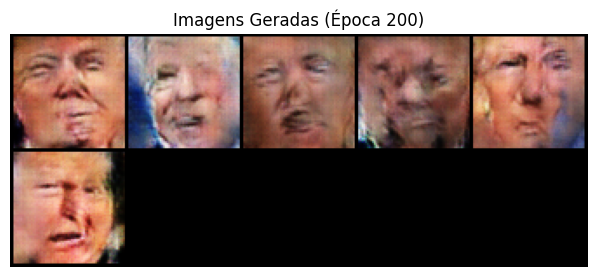

Epoch [201/500] Batch 0/12 Loss D: 0.0886, Loss G: 3.6416
Epoch [202/500] Batch 0/12 Loss D: 0.9622, Loss G: 8.6268
Epoch [203/500] Batch 0/12 Loss D: 0.0943, Loss G: 4.6828
Epoch [204/500] Batch 0/12 Loss D: 0.1193, Loss G: 4.3442
Epoch [205/500] Batch 0/12 Loss D: 0.0837, Loss G: 4.5231
Epoch [206/500] Batch 0/12 Loss D: 0.9551, Loss G: 9.1083
Epoch [207/500] Batch 0/12 Loss D: 0.5260, Loss G: 6.1512
Epoch [208/500] Batch 0/12 Loss D: 0.6782, Loss G: 7.5701
Epoch [209/500] Batch 0/12 Loss D: 0.0925, Loss G: 3.3177
Epoch [210/500] Batch 0/12 Loss D: 0.1469, Loss G: 3.3875
Epoch [211/500] Batch 0/12 Loss D: 0.2651, Loss G: 5.2224
Epoch [212/500] Batch 0/12 Loss D: 0.0971, Loss G: 3.6857
Epoch [213/500] Batch 0/12 Loss D: 0.0796, Loss G: 4.0644
Epoch [214/500] Batch 0/12 Loss D: 0.5135, Loss G: 7.7659
Epoch [215/500] Batch 0/12 Loss D: 0.0605, Loss G: 4.9151
Epoch [216/500] Batch 0/12 Loss D: 0.1583, Loss G: 4.9654
Epoch [217/500] Batch 0/12 Loss D: 3.7468, Loss G: 13.8165
Epoch [218/50

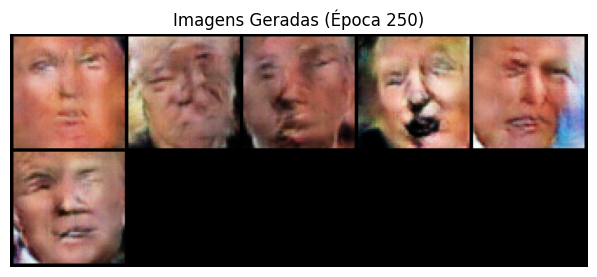

Epoch [251/500] Batch 0/12 Loss D: 0.7066, Loss G: 8.2159
Epoch [252/500] Batch 0/12 Loss D: 0.4712, Loss G: 2.9871
Epoch [253/500] Batch 0/12 Loss D: 0.1442, Loss G: 4.2806
Epoch [254/500] Batch 0/12 Loss D: 0.1452, Loss G: 3.8592
Epoch [255/500] Batch 0/12 Loss D: 0.0932, Loss G: 4.3975
Epoch [256/500] Batch 0/12 Loss D: 0.1659, Loss G: 4.8535
Epoch [257/500] Batch 0/12 Loss D: 0.0763, Loss G: 4.4094
Epoch [258/500] Batch 0/12 Loss D: 0.2304, Loss G: 4.7722
Epoch [259/500] Batch 0/12 Loss D: 0.0763, Loss G: 3.9377
Epoch [260/500] Batch 0/12 Loss D: 0.0703, Loss G: 3.9809
Epoch [261/500] Batch 0/12 Loss D: 0.1215, Loss G: 4.6195
Epoch [262/500] Batch 0/12 Loss D: 0.1979, Loss G: 4.9325
Epoch [263/500] Batch 0/12 Loss D: 0.0731, Loss G: 4.3938
Epoch [264/500] Batch 0/12 Loss D: 0.0839, Loss G: 4.4944
Epoch [265/500] Batch 0/12 Loss D: 0.2228, Loss G: 4.9273
Epoch [266/500] Batch 0/12 Loss D: 0.3528, Loss G: 5.8437
Epoch [267/500] Batch 0/12 Loss D: 0.0850, Loss G: 3.2448
Epoch [268/500

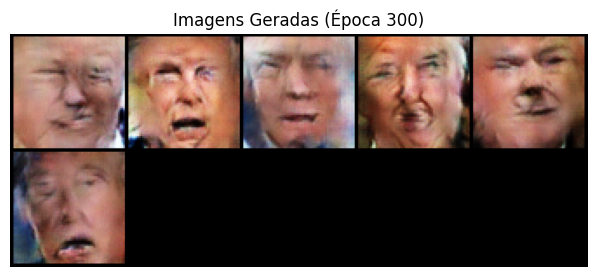

Epoch [301/500] Batch 0/12 Loss D: 0.0745, Loss G: 4.6720
Epoch [302/500] Batch 0/12 Loss D: 0.0757, Loss G: 4.8141
Epoch [303/500] Batch 0/12 Loss D: 0.2415, Loss G: 6.5459
Epoch [304/500] Batch 0/12 Loss D: 0.0735, Loss G: 4.5095
Epoch [305/500] Batch 0/12 Loss D: 0.2170, Loss G: 6.2601
Epoch [306/500] Batch 0/12 Loss D: 0.0599, Loss G: 4.8867
Epoch [307/500] Batch 0/12 Loss D: 0.1620, Loss G: 5.6680
Epoch [308/500] Batch 0/12 Loss D: 0.1445, Loss G: 5.1862
Epoch [309/500] Batch 0/12 Loss D: 0.0423, Loss G: 4.7087
Epoch [310/500] Batch 0/12 Loss D: 0.0396, Loss G: 5.0097
Epoch [311/500] Batch 0/12 Loss D: 0.0735, Loss G: 5.0882
Epoch [312/500] Batch 0/12 Loss D: 0.0320, Loss G: 4.8089
Epoch [313/500] Batch 0/12 Loss D: 0.1296, Loss G: 5.5234
Epoch [314/500] Batch 0/12 Loss D: 0.1759, Loss G: 2.7296
Epoch [315/500] Batch 0/12 Loss D: 0.0850, Loss G: 4.7394
Epoch [316/500] Batch 0/12 Loss D: 0.0934, Loss G: 4.0005
Epoch [317/500] Batch 0/12 Loss D: 0.7982, Loss G: 11.5287
Epoch [318/50

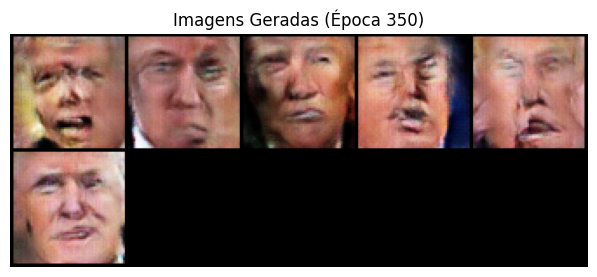

Epoch [351/500] Batch 0/12 Loss D: 0.1873, Loss G: 4.4290
Epoch [352/500] Batch 0/12 Loss D: 1.0416, Loss G: 7.7648
Epoch [353/500] Batch 0/12 Loss D: 0.0808, Loss G: 4.4256
Epoch [354/500] Batch 0/12 Loss D: 0.2430, Loss G: 5.1382
Epoch [355/500] Batch 0/12 Loss D: 0.1323, Loss G: 4.3368
Epoch [356/500] Batch 0/12 Loss D: 0.1367, Loss G: 4.1357
Epoch [357/500] Batch 0/12 Loss D: 0.0659, Loss G: 4.5191
Epoch [358/500] Batch 0/12 Loss D: 0.7067, Loss G: 7.2761
Epoch [359/500] Batch 0/12 Loss D: 0.1527, Loss G: 4.8206
Epoch [360/500] Batch 0/12 Loss D: 0.0751, Loss G: 4.4271
Epoch [361/500] Batch 0/12 Loss D: 0.1595, Loss G: 4.5428
Epoch [362/500] Batch 0/12 Loss D: 0.0743, Loss G: 4.1672
Epoch [363/500] Batch 0/12 Loss D: 0.3126, Loss G: 5.3314
Epoch [364/500] Batch 0/12 Loss D: 0.0521, Loss G: 4.4838
Epoch [365/500] Batch 0/12 Loss D: 0.0737, Loss G: 4.3809
Epoch [366/500] Batch 0/12 Loss D: 0.6664, Loss G: 8.8668
Epoch [367/500] Batch 0/12 Loss D: 0.3883, Loss G: 5.9028
Epoch [368/500

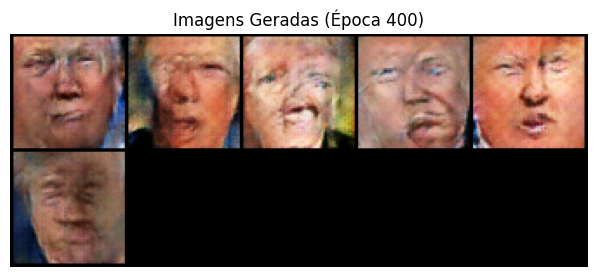

Epoch [401/500] Batch 0/12 Loss D: 2.2341, Loss G: 1.4846
Epoch [402/500] Batch 0/12 Loss D: 1.4682, Loss G: 2.7438
Epoch [403/500] Batch 0/12 Loss D: 2.3115, Loss G: 2.2476
Epoch [404/500] Batch 0/12 Loss D: 1.3256, Loss G: 1.9487
Epoch [405/500] Batch 0/12 Loss D: 0.9525, Loss G: 5.0872
Epoch [406/500] Batch 0/12 Loss D: 0.7467, Loss G: 3.7567
Epoch [407/500] Batch 0/12 Loss D: 1.3553, Loss G: 2.0227
Epoch [408/500] Batch 0/12 Loss D: 0.3914, Loss G: 5.1966
Epoch [409/500] Batch 0/12 Loss D: 0.2360, Loss G: 4.6021
Epoch [410/500] Batch 0/12 Loss D: 0.4969, Loss G: 6.7271
Epoch [411/500] Batch 0/12 Loss D: 0.1639, Loss G: 4.3508
Epoch [412/500] Batch 0/12 Loss D: 0.1875, Loss G: 3.8394
Epoch [413/500] Batch 0/12 Loss D: 0.1891, Loss G: 4.5777
Epoch [414/500] Batch 0/12 Loss D: 0.1380, Loss G: 3.6508
Epoch [415/500] Batch 0/12 Loss D: 0.2087, Loss G: 4.1596
Epoch [416/500] Batch 0/12 Loss D: 0.1240, Loss G: 4.2290
Epoch [417/500] Batch 0/12 Loss D: 0.2661, Loss G: 4.8850
Epoch [418/500

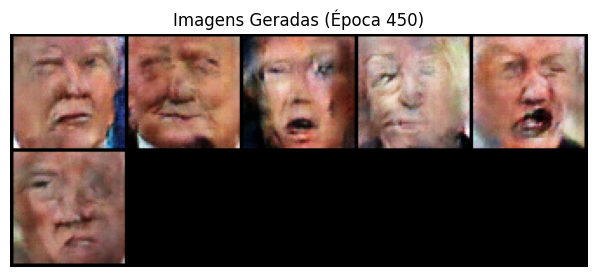

Epoch [451/500] Batch 0/12 Loss D: 0.0974, Loss G: 4.6818
Epoch [452/500] Batch 0/12 Loss D: 0.0854, Loss G: 4.5576
Epoch [453/500] Batch 0/12 Loss D: 0.0569, Loss G: 4.8083
Epoch [454/500] Batch 0/12 Loss D: 0.0493, Loss G: 4.6837
Epoch [455/500] Batch 0/12 Loss D: 0.0656, Loss G: 4.9169
Epoch [456/500] Batch 0/12 Loss D: 0.0579, Loss G: 4.7497
Epoch [457/500] Batch 0/12 Loss D: 0.1666, Loss G: 4.7129
Epoch [458/500] Batch 0/12 Loss D: 0.0838, Loss G: 4.1293
Epoch [459/500] Batch 0/12 Loss D: 0.0694, Loss G: 5.0329
Epoch [460/500] Batch 0/12 Loss D: 0.3699, Loss G: 6.0302
Epoch [461/500] Batch 0/12 Loss D: 0.0559, Loss G: 4.4680
Epoch [462/500] Batch 0/12 Loss D: 0.0697, Loss G: 4.4259
Epoch [463/500] Batch 0/12 Loss D: 0.0659, Loss G: 4.6602
Epoch [464/500] Batch 0/12 Loss D: 0.0636, Loss G: 4.7857
Epoch [465/500] Batch 0/12 Loss D: 0.0627, Loss G: 4.9718
Epoch [466/500] Batch 0/12 Loss D: 0.0480, Loss G: 4.7330
Epoch [467/500] Batch 0/12 Loss D: 0.0551, Loss G: 4.4984
Epoch [468/500

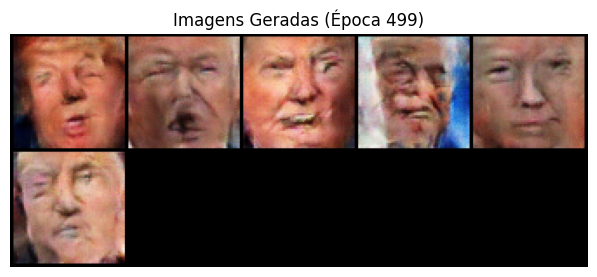

In [14]:
# Treinar o modelo
train_dcgan(generator, discriminator, dataloader, criterion, optimizer_G, optimizer_D, epochs)

Resumo de monitoramento
---------------------

* **`Loss D:`** Idealmente, deve oscilar em torno de 0.5, indicando que o discriminador tem dificuldade em distinguir amostras reais das falsas.
* **`Loss G:`** Deve diminuir ao longo do tempo, mas não deve ser muito baixa, indicando que o gerador está aprendendo a enganar o discriminador, mas não completamente.
* **`Equilíbrio Dinâmico:`** O sucesso de uma GAN depende de um equilíbrio dinâmico entre Loss D e Loss G, onde ambos os modelos estão aprendendo de forma eficaz.

### Image Inversion: Finding a Latent Vector for a Specific Real Image

To make the generator produce an image that corresponds to a specific real image from the dataset, we can perform an 'image inversion' process. This involves optimizing a latent vector `z` such that the image generated by `G(z)` is as close as possible to our target real image.

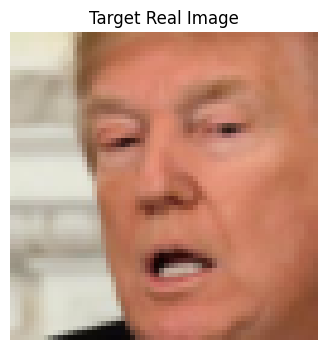

Optimizing latent vector to reconstruct target image...
Inversion Step [500/2000], Loss: 0.1104
Inversion Step [1000/2000], Loss: 0.1022
Inversion Step [1500/2000], Loss: 0.0979
Inversion Step [2000/2000], Loss: 0.0959

Displaying comparison:


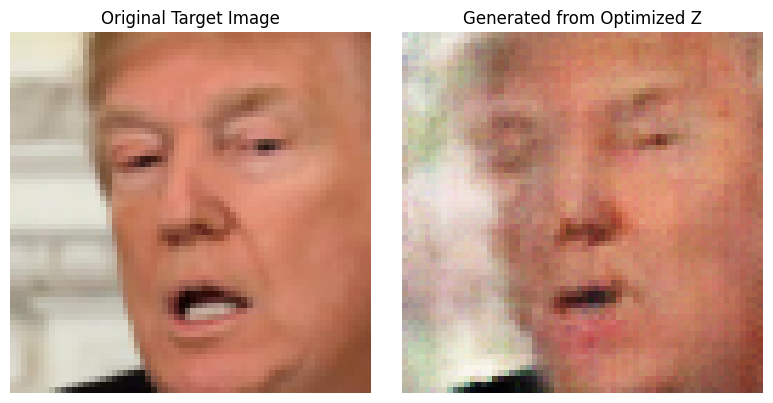

Generator(
  (model): Sequential(
    (0): Linear(in_features=120, out_features=8192, bias=True)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Unflatten(dim=1, unflattened_size=(128, 8, 8))
    (4): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (8): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (11): Tanh()
  )
)

In [15]:
from torch.autograd import Variable
import torch.optim as optim

# 1. Choose a target real image from the dataset
# Let's pick the first image from the first batch for demonstration
target_real_image = next(iter(dataloader))[0][0].unsqueeze(0).to(device) # Get one image, add batch dimension

# Display the target image
plt.figure(figsize=(4, 4))
plt.imshow(target_real_image.cpu().permute(0, 2, 3, 1).squeeze(0) * 0.5 + 0.5) # De-normalize for display
plt.title("Target Real Image")
plt.axis('off')
plt.show()

# 2. Initialize a random latent vector 'z'
inverted_z = Variable(torch.randn(1, latent_dim).to(device), requires_grad=True)

# 3. Define an optimizer for 'z' and a loss function
z_optimizer = optim.Adam([inverted_z], lr=0.01)
inversion_criterion = nn.L1Loss() # L1 loss for pixel-wise similarity

# 4. Optimize 'z' to reconstruct the target image
print("Optimizing latent vector to reconstruct target image...")
num_inversion_steps = 2000 # Number of optimization steps

# Set generator to evaluation mode to handle BatchNorm with batch_size=1
generator.eval()

for step in range(num_inversion_steps):
    z_optimizer.zero_grad()
    generated_image = generator(inverted_z)
    loss = inversion_criterion(generated_image, target_real_image)
    loss.backward()
    z_optimizer.step()

    if (step + 1) % 500 == 0:
        print(f"Inversion Step [{step+1}/{num_inversion_steps}], Loss: {loss.item():.4f}")

# 5. Display the generated image from the optimized 'z' alongside the target
print("\nDisplaying comparison:")
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(target_real_image.cpu().permute(0, 2, 3, 1).squeeze(0) * 0.5 + 0.5)
plt.title("Original Target Image")
plt.axis('off')

plt.subplot(1, 2, 2)
# Detach the tensor from the graph before converting to numpy for plotting
reconstructed_image = generator(inverted_z).detach().cpu().permute(0, 2, 3, 1).squeeze(0) * 0.5 + 0.5
plt.imshow(reconstructed_image)
plt.title("Generated from Optimized Z")
plt.axis('off')

plt.tight_layout()
plt.show()

# Set generator back to training mode if further training is expected
generator.train()